## Visualize baseline model results 

In [1]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import *
import torch.nn.functional as F
from collections import defaultdict

In [2]:
# Set model 
#run_name = '20251017_153007_densenet121.pth'
run_name = '20251017_160759_resnet50.pth'

# Set paths
data_directory = '/data/WHOI-Plankton'
root_directory = os.path.abspath('')
weights_path = os.path.join(root_directory,'Models_results/weights', run_name)
predictions_path = os.path.join(root_directory, 'Models_results/predictions', run_name)
metadata_path = os.path.join(root_directory, 'Models_results/environment', run_name)


In [3]:
# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = predictions[0].numpy()
y_pred = predictions[2].numpy()
y_prob = predictions[1].numpy()

# Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_map = metadata['classes'], metadata['class_map']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']

### Train performance

Model trained for 50 epochs.


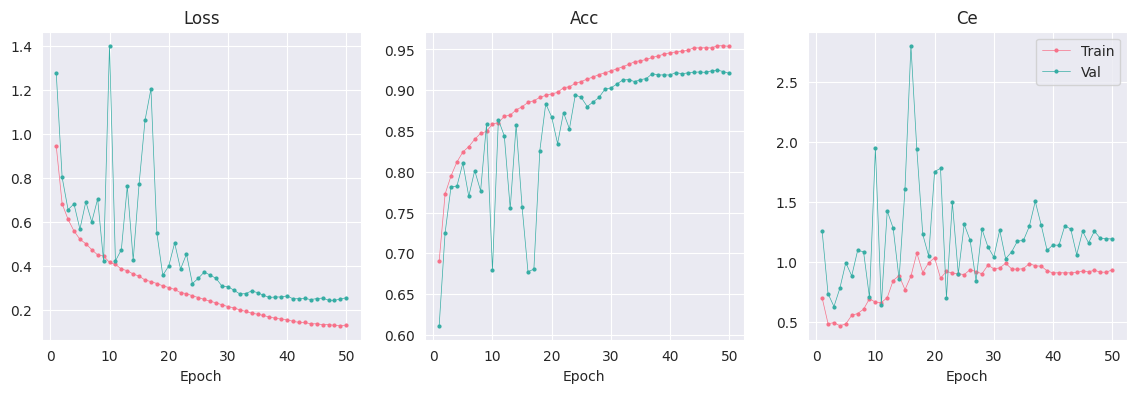

In [4]:
actual_epochs = len(train_metrics['train_acc'])
print(f'Model trained for {actual_epochs} epochs.')

# Plot
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 3, figsize = (14, 4), sharex = True)
palette = sns.color_palette('husl', n_colors = 2)

metrics = ['loss', 'acc', 'ce']
epochs_enum = list(range(1, actual_epochs+1))

for i, metric in enumerate(metrics):
    train_values = train_metrics[f'train_{metric}']
    val_values = train_metrics[f'test_{metric}']

    if metric == 'acc':
        val_values = [x / 100 for x in val_values]

    axes[i].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
    axes[i].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
    
    axes[i].set_title(metric.capitalize())
    axes[i].set_xlabel('Epoch')
    
plt.legend()
plt.show()

### Test performace

In [5]:
# Compute overall metrics
acc = accuracy_score(y_true, y_pred)

prec_avg = precision_score(y_true, y_pred, average = 'macro')
prec_w_avg = precision_score(y_true, y_pred, average = 'weighted')

recall_avg = recall_score(y_true, y_pred, average = 'macro')
recall_w_avg = recall_score(y_true, y_pred, average = 'weighted')

f1_avg = f1_score(y_true, y_pred, average = 'macro')
f1_w_avg = f1_score(y_true, y_pred, average = 'weighted')

ce = log_loss(y_true, y_prob)

# Print
print(f'Accuracy: {acc:.4f}\n')
print(f'Average Precision: {prec_avg:.4f}\nWeighted Precision: {prec_w_avg:.4f}\n')
print(f'Average Recall: {recall_avg:.4f}\nWeighted Recall: {recall_w_avg:.4f}\n')
print(f'Average F1: {f1_avg:.4f}\nWeighted F1: {f1_w_avg:.4f}\n')
print(f'Cross Entropy: {ce:.4f}')

Accuracy: 0.9236

Average Precision: 0.9128
Weighted Precision: 0.9234

Average Recall: 0.9094
Weighted Recall: 0.9236

Average F1: 0.9110
Weighted F1: 0.9235

Cross Entropy: 0.2478


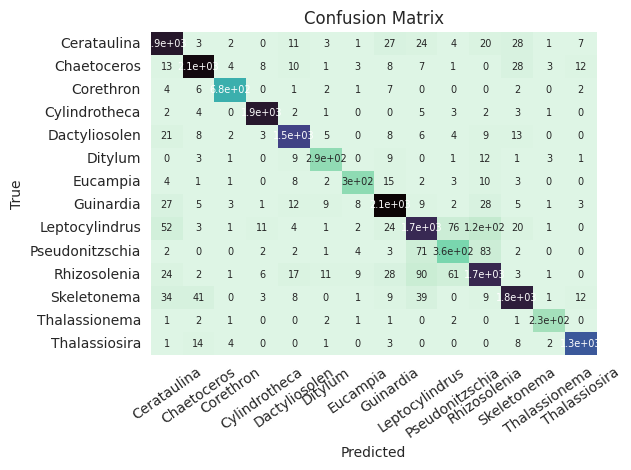

In [6]:
# Get confusion matrix data
cm = confusion_matrix(y_true, y_pred)
annot_kws = {'size': 7}

# Plot
sns.heatmap(cm, annot = True, annot_kws = annot_kws, cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation = 35)

plt.tight_layout()
plt.show()

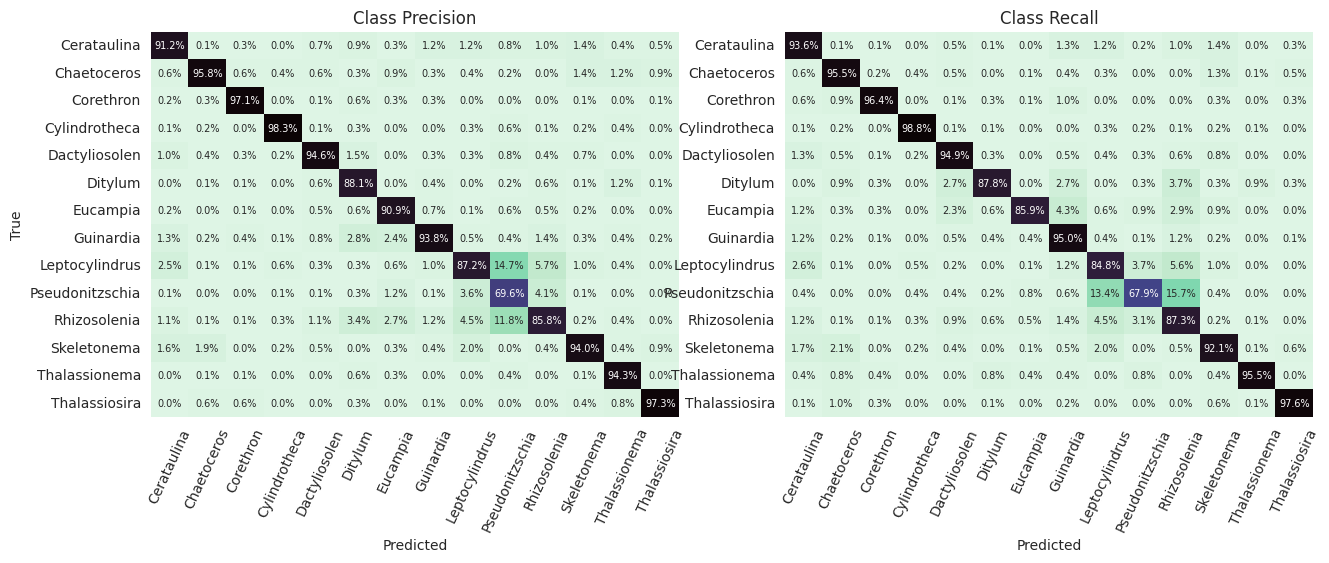

In [7]:
# Get confusion matrix data
cm_col_percent = cm / cm.sum(axis = 0, keepdims = True)
annot_col = np.array([[f"{val:.01%}" for val in row] for row in cm_col_percent])

cm_row_percent = cm / cm.sum(axis = 1, keepdims = True)
annot_row = np.array([[f"{val:.01%}" for val in col] for col in cm_row_percent])

# Plot
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cm_col_percent, annot = annot_col, annot_kws = annot_kws, fmt = '', cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False, ax = axs[0])
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('True')
axs[0].set_title('Class Precision')
axs[0].tick_params(axis = 'x', rotation = 65)

sns.heatmap(cm_row_percent, annot = annot_row, annot_kws = annot_kws, fmt = '', cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False, ax = axs[1])
axs[1].set_xlabel('Predicted')
# axs[1].set_ylabel('True')
axs[1].set_title('Class Recall')
axs[1].tick_params(axis = 'x', rotation = 65)

plt.show()

### Metrics per class

In [8]:
# Compute per class metrics
prec_per_class = precision_score(y_true, y_pred, average = None)
recall_per_class = recall_score(y_true, y_pred, average = None)

# Cross-entropy
y_true_tensor = torch.from_numpy(y_true).long()
y_logit_tensor = torch.from_numpy(y_prob).float().log()

ce_all = F.cross_entropy(y_logit_tensor, y_true_tensor, reduction = 'none')
class_ces = defaultdict(list)

for ce, y in zip(ce_all, y_true_tensor):
    class_ces[int(y)].append(ce.item())

ce_per_class = np.full(len(classes), np.nan)
for clid in range(len(classes)):
    if class_ces[clid]:
        ce_per_class[clid] = np.mean(class_ces[clid])

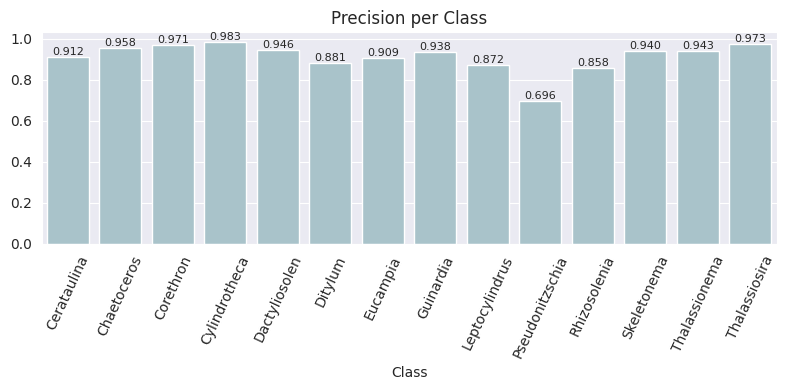

In [9]:
# Precision per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = prec_per_class, color = '#a3c6cf')
plt.title('Precision per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

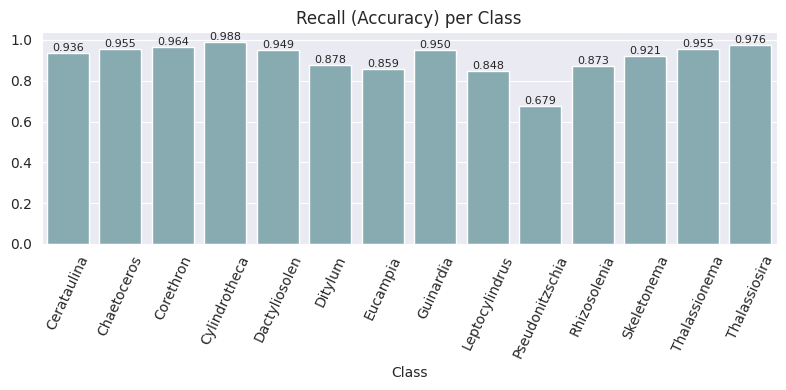

In [10]:
# Recall (accuracy) per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = recall_per_class, color = '#80b0b8')
plt.title('Recall (Accuracy) per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

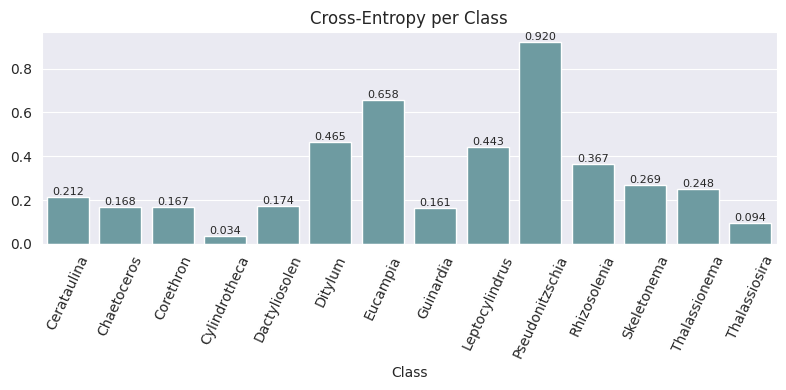

In [11]:
# Cross-entropy per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = ce_per_class, color = '#66a2a9')
plt.title('Cross-Entropy per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()